In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle

In [2]:
df = pd.read_csv('../results/result.csv')
print(f'Shape: {df.shape}')
print(df.head())

idx = df.groupby('n')['time_us'].idxmin()
opt_table = (
    df.loc[idx, ['n', 'threads', 'time_us']]
      .reset_index(drop=True)
      .rename(columns={'threads': 'optimal_threads', 'time_us': 'min_time_us'})
)
print('\nGround truth -- optimal thread count per NTT size:')
print(opt_table.to_string(index=False))

Shape: (195, 3)
    n  threads  time_us
0  64        1   35.209
1  64        2  185.583
2  64        3  208.667
3  64        4  240.125
4  64        5  306.416

Ground truth -- optimal thread count per NTT size:
      n  optimal_threads  min_time_us
     64                1       35.209
    128                1       30.917
    256                1       49.084
    512                1       92.625
   1024                1      192.500
   2048                1      400.292
   4096                4      850.708
   8192                4     1265.500
  16384                4     2213.210
  32768                4     4093.620
  65536                4     7677.330
 131072               16    14841.600
 262144               16    28783.000
 524288               16    57015.400
1048576               16   119546.000


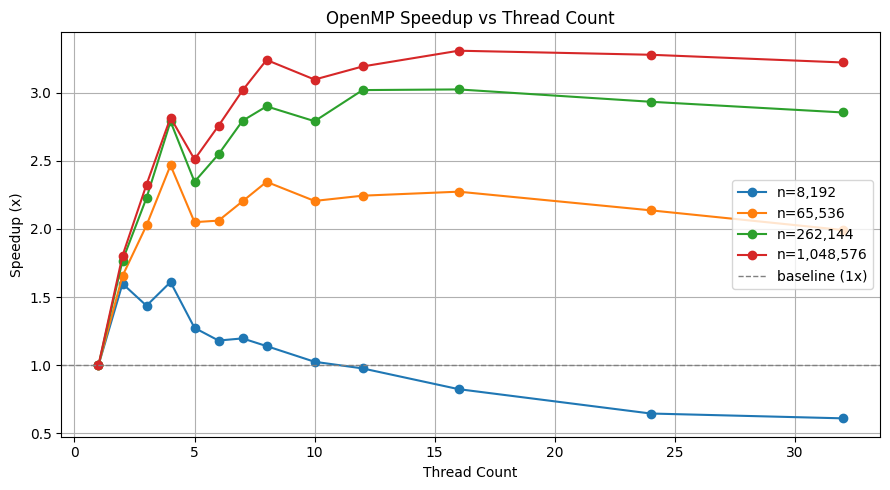

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

for n in [8192, 65536, 262144, 1048576]:
    subset = df[df['n'] == n].sort_values('threads')
    t1 = subset.loc[subset['threads'] == 1, 'time_us'].values[0]
    ax.plot(subset['threads'], t1 / subset['time_us'], marker='o', label=f'n={n:,}')

ax.axhline(y=1, linestyle='--', color='gray', linewidth=1, label='baseline (1x)')
ax.set_xlabel('Thread Count')
ax.set_ylabel('Speedup (x)')
ax.set_title('OpenMP Speedup vs Thread Count')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

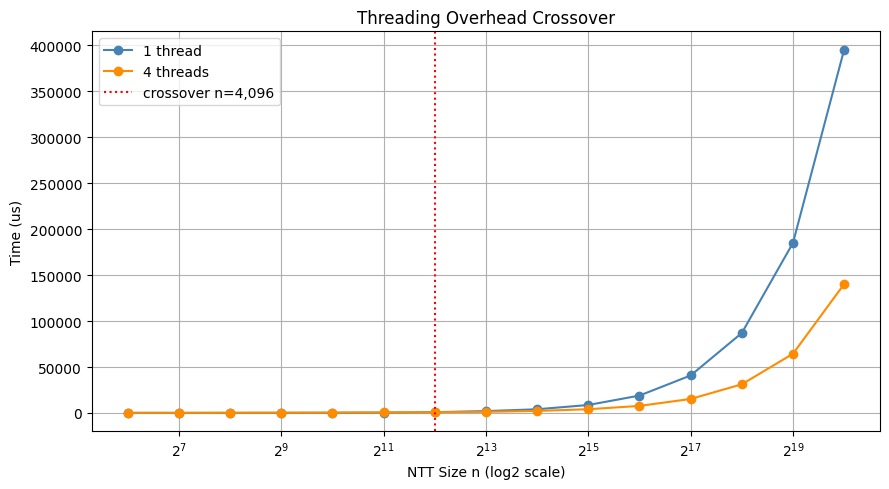

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

for t, label, color in [(1, '1 thread', 'steelblue'), (4, '4 threads', 'darkorange')]:
    sub = df[df['threads'] == t].sort_values('n')
    ax.plot(sub['n'], sub['time_us'], marker='o', label=label, color=color)

ax.set_xscale('log', base=2)
ax.set_xlabel('NTT Size n (log2 scale)')
ax.set_ylabel('Time (us)')
ax.set_title('Threading Overhead Crossover')

t1s = df[df['threads'] == 1].set_index('n')['time_us']
t4s = df[df['threads'] == 4].set_index('n')['time_us']
common = t1s.index.intersection(t4s.index)
diff = t4s[common] - t1s[common]
crossover_ns = diff[diff <= 0].index
if len(crossover_ns):
    cx = crossover_ns[0]
    ax.axvline(x=cx, linestyle=':', color='red', linewidth=1.5, label=f'crossover n={cx:,}')

ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [5]:
df['log2_n'] = np.log2(df['n'])
n_vals = df['n'].values

X = df[['log2_n', 'threads']].values.astype(np.float32)
y = np.log1p(df['time_us'].values).astype(np.float32)  # compress 4-decade range for stable MSE

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test, n_train, n_test = train_test_split(
    X_scaled, y, n_vals, test_size=0.2, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

opt_map = df.loc[df.groupby('n')['time_us'].idxmin()].set_index('n')['threads'].to_dict()

print(f'Train: {len(X_train)} rows  |  Test: {len(X_test)} rows')
print(f'Feature shape: {X_train_t.shape}  |  Target shape: {y_train_t.shape}')

Train: 156 rows  |  Test: 39 rows
Feature shape: torch.Size([156, 2])  |  Target shape: torch.Size([156, 1])


In [6]:
class CostModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


model     = CostModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters())}')

CostModel(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 2305


Epoch  100  |  Train MSE:          6.1  |  Test MSE:          5.5
Epoch  200  |  Train MSE:          1.2  |  Test MSE:          1.3
Epoch  300  |  Train MSE:          0.5  |  Test MSE:          0.6
Epoch  400  |  Train MSE:          0.1  |  Test MSE:          0.1
Epoch  500  |  Train MSE:          0.1  |  Test MSE:          0.1


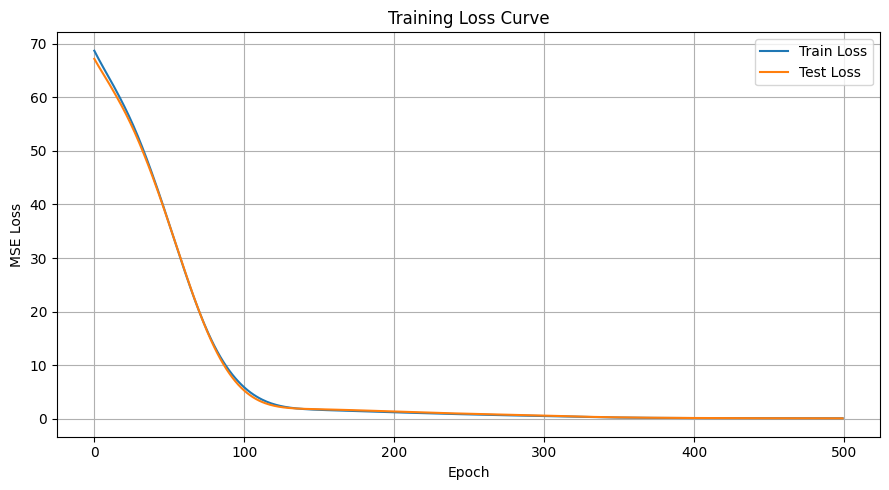

In [7]:
train_losses, test_losses = [], []

for epoch in range(1, 501):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()

    train_losses.append(loss.item())
    test_losses.append(test_loss)

    if epoch % 100 == 0:
        print(f'Epoch {epoch:4d}  |  Train MSE: {loss.item():12.1f}  |  Test MSE: {test_loss:12.1f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_losses, label='Train Loss')
ax.plot(test_losses,  label='Test Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss Curve')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

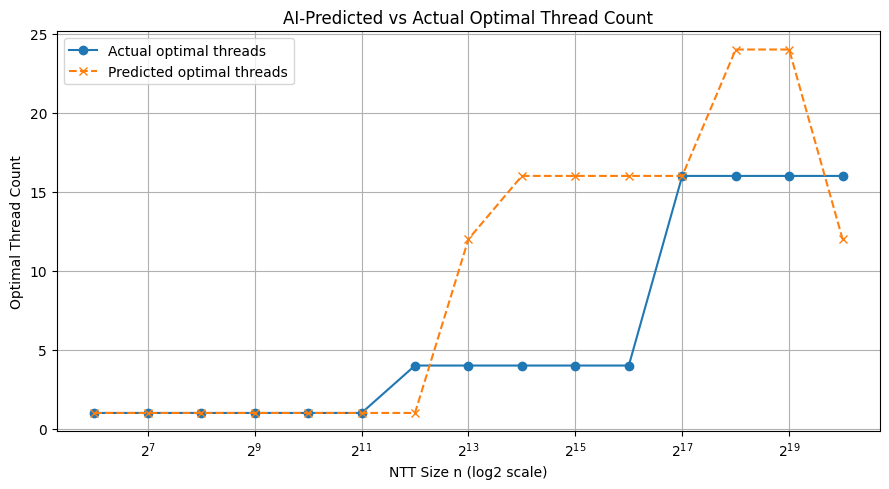

Accuracy: 7/15 = 46.7%


In [8]:
all_threads = sorted(df['threads'].unique())
test_ns     = sorted(set(n_test))

predicted_opts, actual_opts = [], []

model.eval()
with torch.no_grad():
    for n_val in test_ns:
        rows  = np.array([[np.log2(n_val), t] for t in all_threads], dtype=np.float32)
        preds = model(torch.tensor(scaler.transform(rows))).squeeze().numpy()
        predicted_opts.append(all_threads[int(np.argmin(preds))])
        actual_opts.append(opt_map[n_val])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(test_ns, actual_opts,    marker='o', linestyle='-',  label='Actual optimal threads')
ax.plot(test_ns, predicted_opts, marker='x', linestyle='--', label='Predicted optimal threads')
ax.set_xscale('log', base=2)
ax.set_xlabel('NTT Size n (log2 scale)')
ax.set_ylabel('Optimal Thread Count')
ax.set_title('AI-Predicted vs Actual Optimal Thread Count')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

correct = sum(p == a for p, a in zip(predicted_opts, actual_opts))
print(f'Accuracy: {correct}/{len(test_ns)} = {100 * correct / len(test_ns):.1f}%')

In [9]:
torch.save(model.state_dict(), 'api/cost_model.pt')
with open('api/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved: api/cost_model.pt')
print('Saved: api/scaler.pkl')

Saved: api/cost_model.pt
Saved: api/scaler.pkl
